# 教程 2：三重配准（Triple Collocation）入门 🎓

## 写给大一新生的数据融合魔法课

> 你有没有想过：**如果你不知道正确答案，怎么判断谁的答案更准确？**
>
> 这就是三重配准（Triple Collocation）要解决的神奇问题！

---

## 🎯 学习目标

通过本教程，你将学会：
1. 理解三重配准的核心思想（用直觉，不用公式！）
2. 用 Python 模拟观测数据
3. 调用 `collocation.tc` 计算误差
4. 验证算法的神奇效果

**预备知识**：只需要会 Python 基础语法，不需要懂复杂的矩阵代数！

---

## 📖 故事时间：三把尺子测操场

想象你是体育老师的助手，需要测量学校操场的长度。你有三把尺子：

| 尺子 | 特点 | 测量误差 |
|------|------|----------|
| 🟢 尺子 A | 体育器材室的专业尺子 | 误差小 |
| 🟡 尺子 B | 美术老师借来的卷尺 | 误差中等 |
| 🔴 尺子 C | 学生从家里带来的旧尺子 | 误差较大 |

### 问题来了 🤔

你用三把尺子各测了一次：
- 尺子 A 说：100.2 米
- 尺子 B 说：99.8 米  
- 尺子 C 说：101.5 米

**真实长度是多少？哪把尺子更准确？**

如果你手里有一把"完美尺子"（真值），那就简单了——直接比较就行。但问题是：**你根本不知道真实长度！**

### 三重配准的魔法 ✨

三重配准的神奇之处在于：**即使不知道真值，只要三个测量结果都包含同一个真值的信息，我们就能估算出每个测量的误差大小！**

核心直觉：
> 如果两把尺子测量的结果越接近，说明它们可能都很准确；
> 如果一把尺子总是和其他两把不一样，那它可能误差比较大。

这就像考试时的"三角验证"：如果班上最好的三个学生答案一致，那个答案很可能是对的！

---

## 🔧 环境设置

In [1]:
# 设置路径，让 Python 找到 collocation 包
import sys
sys.path.insert(0, '..')  # 回到上一级目录

# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt

# 导入三重配准方法
from collocation import tc

# 设置中文字体（如果系统没有中文字体，图表会用英文替代）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证结果可重复
np.random.seed(42)

print('✅ 环境设置完成！准备开始神奇的三重配准之旅！')

✅ 环境设置完成！准备开始神奇的三重配准之旅！


---

## 🌊 第一步：构造"真实信号"

在现实中，我们不知道真值。但在教学中，我们可以**先假装知道真值**，然后看看算法能不能把它找出来！

我们用正弦波来模拟一个随时间变化的物理量（比如土壤湿度）：

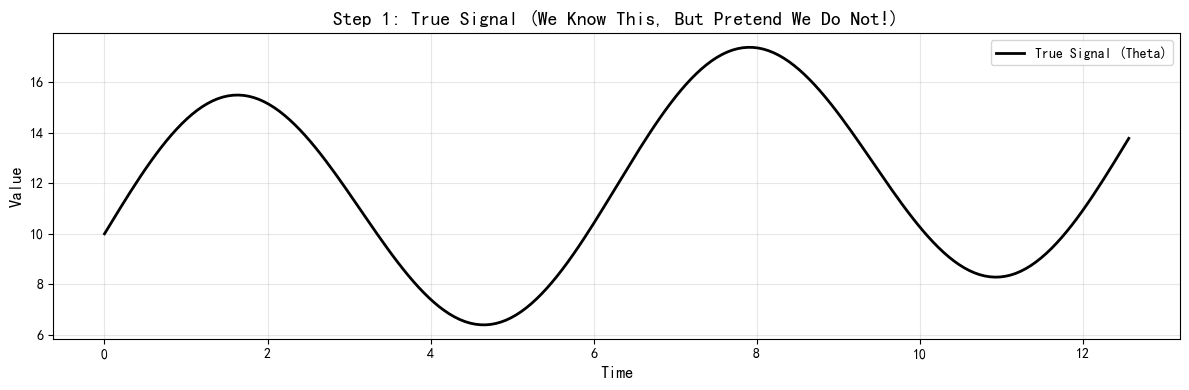

真实信号范围: [6.41, 17.36]


In [2]:
# 模拟 200 个时间点
n_samples = 200
time = np.linspace(0, 4 * np.pi, n_samples)  # 0 到 4π，两个完整周期

# 构造真实信号：正弦波 + 一点趋势
true_signal = 10 + 5 * np.sin(time) + 0.3 * time

# 可视化
plt.figure(figsize=(12, 4))
plt.plot(time, true_signal, 'k-', linewidth=2, label='True Signal (Theta)')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Step 1: True Signal (We Know This, But Pretend We Do Not!)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'真实信号范围: [{true_signal.min():.2f}, {true_signal.max():.2f}]')

---

## 🎭 第二步：模拟三个"传感器"的观测

现在，假设我们有三个传感器（相当于三把尺子），每个都在测量同一个真实信号，但各自有不同的噪声水平：

| 传感器 | 噪声标准差 (σ) | 噪声方差 (σ²) | 质量 |
|--------|----------------|---------------|------|
| 🟢 传感器 1 | 0.5 | 0.25 | 最好 |
| 🟡 传感器 2 | 1.0 | 1.00 | 中等 |
| 🔴 传感器 3 | 2.0 | 4.00 | 较差 |

**观测模型**：观测值 = 真实值 + 高斯白噪声

In [3]:
# 设置三个传感器的噪声标准差
sigma_1 = 0.5   # 传感器1：误差小
sigma_2 = 1.0   # 传感器2：误差中等
sigma_3 = 2.0   # 传感器3：误差大

# 生成噪声
noise_1 = sigma_1 * np.random.randn(n_samples)
noise_2 = sigma_2 * np.random.randn(n_samples)
noise_3 = sigma_3 * np.random.randn(n_samples)

# 生成观测值 = 真实信号 + 噪声
obs_1 = true_signal + noise_1
obs_2 = true_signal + noise_2
obs_3 = true_signal + noise_3

print('✅ 三个传感器的观测数据已生成！')
print(f'\n📊 噪声方差（这是我们设定的"真相"）：')
print(f'   传感器 1: σ² = {sigma_1**2:.2f}')
print(f'   传感器 2: σ² = {sigma_2**2:.2f}')
print(f'   传感器 3: σ² = {sigma_3**2:.2f}')

✅ 三个传感器的观测数据已生成！

📊 噪声方差（这是我们设定的"真相"）：
   传感器 1: σ² = 0.25
   传感器 2: σ² = 1.00
   传感器 3: σ² = 4.00


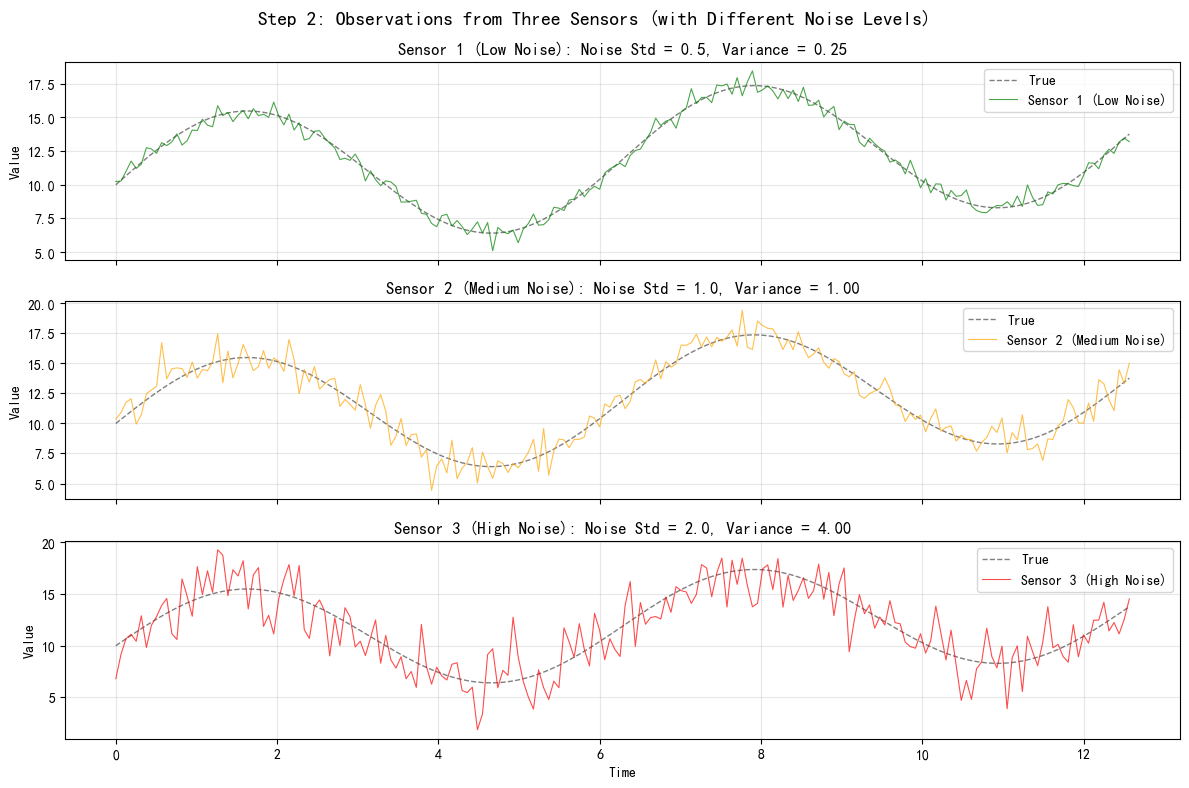

In [4]:
# 可视化三个传感器的观测
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

colors = ['green', 'orange', 'red']
labels = ['Sensor 1 (Low Noise)', 'Sensor 2 (Medium Noise)', 'Sensor 3 (High Noise)']
observations = [obs_1, obs_2, obs_3]
sigmas = [sigma_1, sigma_2, sigma_3]

for ax, obs, color, label, sigma in zip(axes, observations, colors, labels, sigmas):
    ax.plot(time, true_signal, 'k--', linewidth=1, alpha=0.5, label='True')
    ax.plot(time, obs, color=color, alpha=0.7, linewidth=0.8, label=label)
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')
    ax.set_title(f'{label}: Noise Std = {sigma:.1f}, Variance = {sigma**2:.2f}')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.suptitle('Step 2: Observations from Three Sensors (with Different Noise Levels)', fontsize=14)
plt.tight_layout()
plt.show()

**观察**：
- 🟢 传感器 1（绿色）：紧密跟随真实信号（黑色虚线）
- 🟡 传感器 2（橙色）：有一定波动
- 🔴 传感器 3（红色）：波动最大，有时偏离真值很多

---

## ✨ 第三步：三重配准的魔法时刻！

现在，**假装我们不知道真实信号**。我们只有三个传感器的观测数据。

问题：**能不能只用这三个观测数据，估算出每个传感器的误差有多大？**

答案：**可以！这就是三重配准的神奇之处！**

In [5]:
# 准备数据：三列分别是三个传感器的观测
data = np.column_stack([obs_1, obs_2, obs_3])

print(f'数据形状: {data.shape}')
print(f'每一行是一个时间点，每一列是一个传感器')

数据形状: (200, 3)
每一行是一个时间点，每一列是一个传感器


In [6]:
# 调用三重配准！
EeeT, SNR, rho2, fMSE = tc(data)

print('🎉 三重配准计算完成！')
print('\n' + '='*60)

🎉 三重配准计算完成！



---

## 🔍 第四步：见证奇迹的时刻！

让我们对比**三重配准估算的误差**和**真实设定的误差**：

In [7]:
# 提取估算的误差方差（EeeT 的对角线元素）
estimated_var = np.diag(EeeT)

# 真实的误差方差
true_var = np.array([sigma_1**2, sigma_2**2, sigma_3**2])

# 打印对比结果
print('\n🎯 误差方差对比（关键结果！）')
print('='*60)
print(f'{"传感器":<10} {"真实方差 (σ²)":<15} {"TC估算方差":<15} {"相对误差":<15}')
print('-'*60)

for i in range(3):
    rel_error = abs(estimated_var[i] - true_var[i]) / true_var[i] * 100
    print(f'传感器 {i+1:<3} {true_var[i]:<15.4f} {estimated_var[i]:<15.4f} {rel_error:<14.1f}%')

print('='*60)
print('\n✨ 神奇吧！TC 在不知道真值的情况下，估算出了误差方差！')


🎯 误差方差对比（关键结果！）
传感器        真实方差 (σ²)       TC估算方差          相对误差           
------------------------------------------------------------
传感器 1   0.2500          0.2438          2.5           %
传感器 2   1.0000          0.8492          15.1          %
传感器 3   4.0000          4.1628          4.1           %

✨ 神奇吧！TC 在不知道真值的情况下，估算出了误差方差！


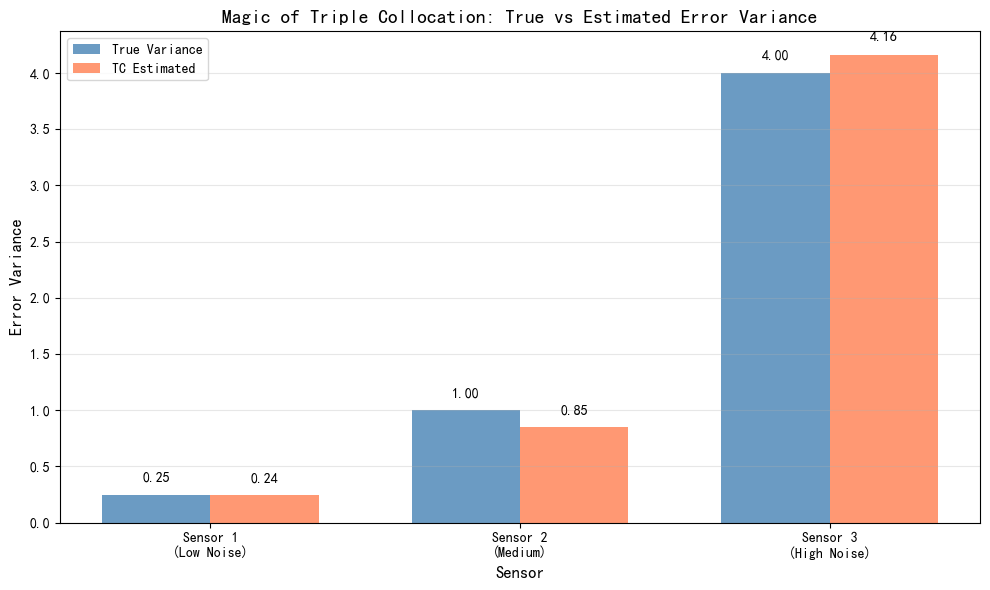

In [8]:
# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(3)
width = 0.35

bars1 = ax.bar(x - width/2, true_var, width, label='True Variance', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, estimated_var, width, label='TC Estimated', color='coral', alpha=0.8)

ax.set_xlabel('Sensor', fontsize=12)
ax.set_ylabel('Error Variance', fontsize=12)
ax.set_title('Magic of Triple Collocation: True vs Estimated Error Variance', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Sensor 1\n(Low Noise)', 'Sensor 2\n(Medium)', 'Sensor 3\n(High Noise)'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar1, bar2, tv, ev in zip(bars1, bars2, true_var, estimated_var):
    ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.1, 
            f'{tv:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.1, 
            f'{ev:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---

## 📊 第五步：更多洞察

三重配准还给我们提供了其他有用的指标：

In [9]:
# 打印更多结果
print('\n📈 信噪比 (SNR - Signal-to-Noise Ratio)')
print('   SNR 越高，说明信号相对于噪声越强，传感器越好')
print('-'*50)
for i in range(3):
    print(f'   传感器 {i+1}: SNR = {SNR[i]:.2f}')

print('\n📊 与真值的相关性 (ρ²)')
print('   ρ² 越高（接近1），说明传感器与真值的相关性越强')
print('-'*50)
for i in range(3):
    print(f'   传感器 {i+1}: ρ² = {rho2[i]:.4f}')

print('\n📉 相对误差比例 (fMSE - Fractional MSE)')
print('   fMSE = 1 - ρ²，表示误差占总变异的比例，越低越好')
print('-'*50)
for i in range(3):
    print(f'   传感器 {i+1}: fMSE = {fMSE[i]:.4f}')


📈 信噪比 (SNR - Signal-to-Noise Ratio)
   SNR 越高，说明信号相对于噪声越强，传感器越好
--------------------------------------------------
   传感器 1: SNR = 42.49
   传感器 2: SNR = 12.98
   传感器 3: SNR = 2.33

📊 与真值的相关性 (ρ²)
   ρ² 越高（接近1），说明传感器与真值的相关性越强
--------------------------------------------------
   传感器 1: ρ² = 0.9770
   传感器 2: ρ² = 0.9285
   传感器 3: ρ² = 0.6996

📉 相对误差比例 (fMSE - Fractional MSE)
   fMSE = 1 - ρ²，表示误差占总变异的比例，越低越好
--------------------------------------------------
   传感器 1: fMSE = 0.0230
   传感器 2: fMSE = 0.0715
   传感器 3: fMSE = 0.3004


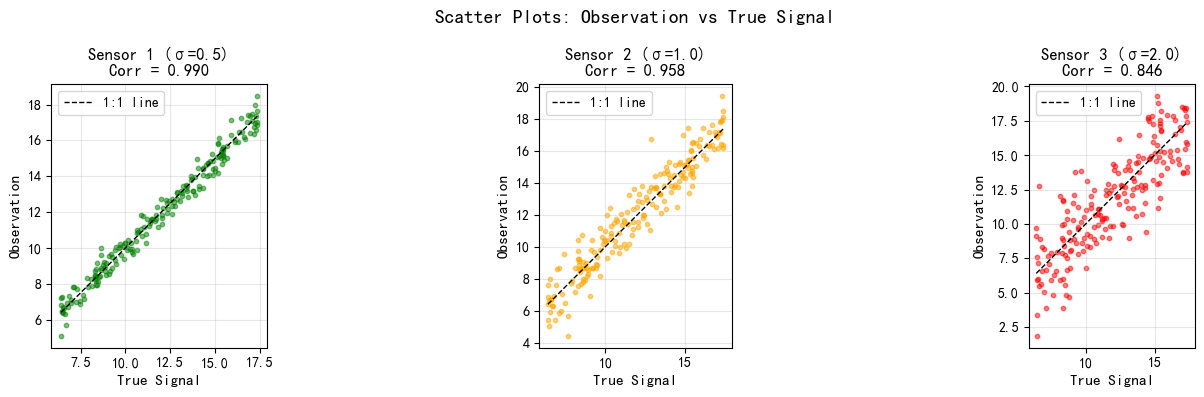


💡 观察：噪声越大的传感器，散点越分散，与 1:1 线的偏离越大


In [10]:
# 散点图：观测值 vs 真值
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (obs, ax, color, sigma) in enumerate(zip(observations, axes, colors, sigmas)):
    ax.scatter(true_signal, obs, alpha=0.5, s=10, c=color)
    ax.plot([true_signal.min(), true_signal.max()], 
            [true_signal.min(), true_signal.max()], 
            'k--', linewidth=1, label='1:1 line')
    
    # 计算实际相关系数
    corr = np.corrcoef(true_signal, obs)[0, 1]
    
    ax.set_xlabel('True Signal', fontsize=11)
    ax.set_ylabel('Observation', fontsize=11)
    ax.set_title(f'Sensor {i+1} (σ={sigma})\nCorr = {corr:.3f}', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Scatter Plots: Observation vs True Signal', fontsize=14)
plt.tight_layout()
plt.show()

print('\n💡 观察：噪声越大的传感器，散点越分散，与 1:1 线的偏离越大')

---

## 🧠 核心概念总结

### 三重配准是什么？

三重配准（Triple Collocation, TC）是一种**无需真值即可估计误差**的方法。

### 它是如何工作的？

核心假设：
1. **三个产品都在测量同一个"真值"**
2. **每个产品的误差是独立的**（你的噪声和我的噪声没关系）
3. **误差是零均值的**（平均来说不会系统性地偏高或偏低）

在这些假设下，通过分析三个产品之间的**协方差关系**，可以分离出每个产品的误差。

### 类比理解

想象三个学生 A、B、C 做同一道题：
- 如果 A 和 B 答案相似，A 和 C 答案也相似，但 B 和 C 差别很大
- 那么 A 可能是最准确的！

TC 就是用数学方法，从"谁和谁更像"这个信息中，反推出"谁的误差更大"。

---

## 🎮 课后练习

试着修改下面的代码，看看不同情况下 TC 的表现：

1. **调整噪声水平**：如果三个传感器噪声一样大，TC 能分辨吗？
2. **减少样本数**：把 `n_samples` 改成 50，看看估算还准吗？
3. **极端噪声**：把一个传感器的噪声调到很大（比如 σ=10），看看会发生什么

In [11]:
# 🎮 练习区域：修改这里的参数试试！

# 参数设置
n_samples_new = 200        # 尝试改成 50, 100, 500
sigma_1_new = 0.5          # 传感器1的噪声
sigma_2_new = 1.0          # 传感器2的噪声  
sigma_3_new = 2.0          # 传感器3的噪声（尝试改成 5.0 或 0.5）

# 重新生成数据
np.random.seed(123)  # 换个种子
time_new = np.linspace(0, 4 * np.pi, n_samples_new)
true_new = 10 + 5 * np.sin(time_new)

obs_1_new = true_new + sigma_1_new * np.random.randn(n_samples_new)
obs_2_new = true_new + sigma_2_new * np.random.randn(n_samples_new)
obs_3_new = true_new + sigma_3_new * np.random.randn(n_samples_new)

# 运行 TC
data_new = np.column_stack([obs_1_new, obs_2_new, obs_3_new])
EeeT_new, SNR_new, rho2_new, fMSE_new = tc(data_new)

# 打印结果
print('\n🔬 实验结果')
print('='*50)
true_var_new = [sigma_1_new**2, sigma_2_new**2, sigma_3_new**2]
est_var_new = np.diag(EeeT_new)

for i in range(3):
    err = abs(est_var_new[i] - true_var_new[i]) / true_var_new[i] * 100
    print(f'传感器 {i+1}: 真实方差={true_var_new[i]:.2f}, 估算={est_var_new[i]:.2f}, 误差={err:.1f}%')


🔬 实验结果
传感器 1: 真实方差=0.25, 估算=0.34, 误差=36.5%
传感器 2: 真实方差=1.00, 估算=0.79, 误差=21.0%
传感器 3: 真实方差=4.00, 估算=4.05, 误差=1.3%


---

## 📚 延伸阅读

如果你想深入了解三重配准，可以参考：

1. **Stoffelen (1998)** - Triple Collocation 的开山之作
2. **Gruber et al. (2016)** - 三重配准的现代应用综述
3. 本包的其他教程：`simple_average_tutorial.ipynb` - 简单平均法

---

## 🎉 恭喜完成！

你已经学会了：
- ✅ 三重配准的核心思想
- ✅ 如何用 Python 模拟观测数据
- ✅ 调用 `collocation.tc` 进行分析
- ✅ 理解并可视化分析结果

**下一步**：学习如何使用 TC 估算的误差来进行数据融合（加权平均），制作出比任何单一传感器都更准确的融合产品！